we'll build a CNN using Keras to use it classifying thousands of pictures in six different categories

Data link : https://www.kaggle.com/puneet6060/intel-image-classification

#Import Libraries

In [1]:
!pip install opencv-python
!pip install tensorflow

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import os
import cv2
import glob as gb

import tensorflow as tf
import keras

#define the path ( to swtich it between jupyter notebook & kaggle kernel)

In [3]:
os.getcwd()

'D:\\Amit_Material\\cv\\cv\\session4'

In [2]:
train_path='cnn_img/seg_train'
test_path='cnn_img/seg_test'
pred_path='cnn_img/seg_pred'

# Open Folders

now let's first check the Train folder to have a look to its content

In [3]:
for folder in os.listdir(train_path):
    images=gb.glob(pathname=str(train_path +'/'+folder+'/*.jpg'))
    print(f'For training data , found {len(images)} in folder {folder}')

For training data , found 70 in folder buildings
For training data , found 70 in folder forest
For training data , found 70 in folder glacier
For training data , found 60 in folder mountain
For training data , found 90 in folder sea
For training data , found 80 in folder street


In [4]:
for folder in os.listdir(test_path):
    images=gb.glob(pathname=str(test_path +'/'+folder+'/*.jpg'))
    print(f'For training data , found {len(images)} in folder {folder}')

For training data , found 100 in folder buildings
For training data , found 80 in folder forest
For training data , found 90 in folder glacier
For training data , found 90 in folder mountain
For training data , found 80 in folder sea
For training data , found 120 in folder street


In [5]:
files = gb.glob(pathname= str(pred_path +'/*.jpg'))
print(f'For Prediction data , found {len(files)}')

For Prediction data , found 90


#Checking Images
now we need to heck the images sizes , to know ow they looks like

since we have 6 categories , we first need to create a dictionary with their names & indices , also create a function to get the code back

In [6]:
code = {'buildings':0 ,'forest':1,'glacier':2,'mountain':3,'sea':4,'street':5}

def get_code(n):
    for x,y in code.items():
        if n==y:
            return x

In [7]:
get_code(3)

'mountain'

In [8]:
sizes=[]
for folder in os.listdir(train_path):
    images=gb.glob(pathname=str(train_path +'/'+folder+'/*.jpg'))

    for img in images:
        image=plt.imread(img)
        sizes.append(image.shape)

pd.Series(sizes).value_counts()

(150, 150, 3)    438
(113, 150, 3)      1
(140, 150, 3)      1
Name: count, dtype: int64

In [9]:
sizes=[]
for folder in os.listdir(test_path):
    images=gb.glob(pathname=str(test_path +'/'+folder+'/*.jpg'))

    for img in images:
        image=plt.imread(img)
        sizes.append(image.shape)

pd.Series(sizes).value_counts()

(150, 150, 3)    560
Name: count, dtype: int64

In [10]:
size = []
files = gb.glob(pathname= str(pred_path +'/*.jpg'))
for file in files:
    image = plt.imread(file)
    size.append(image.shape)
pd.Series(size).value_counts()

(150, 150, 3)    90
Name: count, dtype: int64

ok , since almost all of pictures are 150,150,3 , we can feel comfort in using all pictures in our model , after resizing it in a specific amount

#Reading Images
now it's time to read all images & convert it into arrays

first we'll create a variable s , which refer to size , so we can change it easily

let's use now size = 100 , so it will be suitable amount to contain accuracy without losing so much time in training

In [11]:
x_train=[]
y_train=[]

for folder in os.listdir(train_path):
    images=gb.glob(pathname=str(train_path +'/'+folder+'/*.jpg'))

    for img in images:
        image=plt.imread(img)
        image=cv2.resize(image,(100,100))
        x_train.append(list(image))
        y_train.append(code[folder])

In [12]:
print(f'we have {len(x_train)} items in X_train')

we have 440 items in X_train


also we have have a look to random pictures in X_train , and to adjust their title using the y value

In [13]:
x_test=[]
y_test=[]

for folder in os.listdir(test_path):
    images=gb.glob(pathname=str(test_path +'/'+folder+'/*.jpg'))

    for img in images:
        image=plt.imread(img)
        image=cv2.resize(image,(100,100))
        x_test.append(list(image))
        y_test.append(code[folder])

In [14]:
print(f'we have {len(x_test)} items in x_test')

we have 560 items in x_test


In [15]:
x_pred = []
files = gb.glob(pathname= str(pred_path + '/*.jpg'))
for file in files:
    image = cv2.imread(file)
    image_array = cv2.resize(image , (100,100))
    x_pred.append(list(image_array))

In [16]:
print(f'we have {len(x_pred)} items in X_pred')

we have 90 items in X_pred


In [17]:
x_train=np.array(x_train)
x_test=np.array(x_test)

y_train=np.array(y_train)
y_test=np.array(y_test)

x_pred=np.array(x_pred)

In [18]:
print(x_train.shape)
print(x_test.shape)

print(y_train.shape)
print(y_test.shape)

print(x_pred.shape)

(440, 100, 100, 3)
(560, 100, 100, 3)
(440,)
(560,)
(90, 100, 100, 3)


In [19]:
KerasModel=keras.models.Sequential([
    keras.layers.Conv2D(200,activation='relu',kernel_size=(3,3),input_shape=(100,100,3)),
    keras.layers.Conv2D(120,activation='relu',kernel_size=(3,3)),
    keras.layers.MaxPool2D(4,4),
    keras.layers.Conv2D(80,activation='relu',kernel_size=(3,3)),
    keras.layers.Conv2D(50,activation='relu',kernel_size=(3,3)),
    keras.layers.Conv2D(40,activation='relu',kernel_size=(3,3)),
    keras.layers.MaxPool2D(4,4),
    keras.layers.Flatten(),
    keras.layers.Dense(30,activation='relu'),
    keras.layers.Dense(10,activation='relu'),
    keras.layers.Dropout(rate=.5),
    keras.layers.Dense(6,activation='softmax')
])

C:\Users\dell\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
KerasModel.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [22]:
model=KerasModel.fit(x_train, y_train, epochs=2,batch_size=64, verbose=1)

Epoch 1/2
7/7 ━━━━━━━━━━━━━━━━━━━━ 97s 12s/step - accuracy: 0.1824 - loss: 7.9051
Epoch 2/2
7/7 ━━━━━━━━━━━━━━━━━━━━ 83s 12s/step - accuracy: 0.1944 - loss: 2.2562


In [23]:
loss,accuracy=KerasModel.evaluate(x_test,y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 829ms/step - accuracy: 0.0865 - loss: 1.8460


In [24]:
print(f'loss is {loss}')
print(f'accuracy is {accuracy}')

loss is 1.8791475296020508
accuracy is 0.13750000298023224


In [25]:
y_result = KerasModel.predict(x_pred)

y_result

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 986ms/step


array([[0.16657   , 0.16721414, 0.16521211, 0.1682326 , 0.16660471,
        0.16616638],
       [0.16657   , 0.16721414, 0.16521211, 0.1682326 , 0.16660471,
        0.16616638],
       [0.16657   , 0.16721414, 0.16521211, 0.1682326 , 0.16660471,
        0.16616638],
       [0.16657   , 0.16721414, 0.16521211, 0.1682326 , 0.16660471,
        0.16616638],
       [0.16657   , 0.16721414, 0.16521211, 0.1682326 , 0.16660471,
        0.16616638],
       [0.16657   , 0.16721414, 0.16521211, 0.1682326 , 0.16660471,
        0.16616638],
       [0.16657   , 0.16721414, 0.16521211, 0.1682326 , 0.16660471,
        0.16616638],
       [0.16657   , 0.16721414, 0.16521211, 0.1682326 , 0.16660471,
        0.16616638],
       [0.16657   , 0.16721414, 0.16521211, 0.1682326 , 0.16660471,
        0.16616638],
       [0.16657   , 0.16721414, 0.16521211, 0.1682326 , 0.16660471,
        0.16616638],
       [0.16657   , 0.16721414, 0.16521211, 0.1682326 , 0.16660471,
        0.16616638],
       [0.16657   , 0

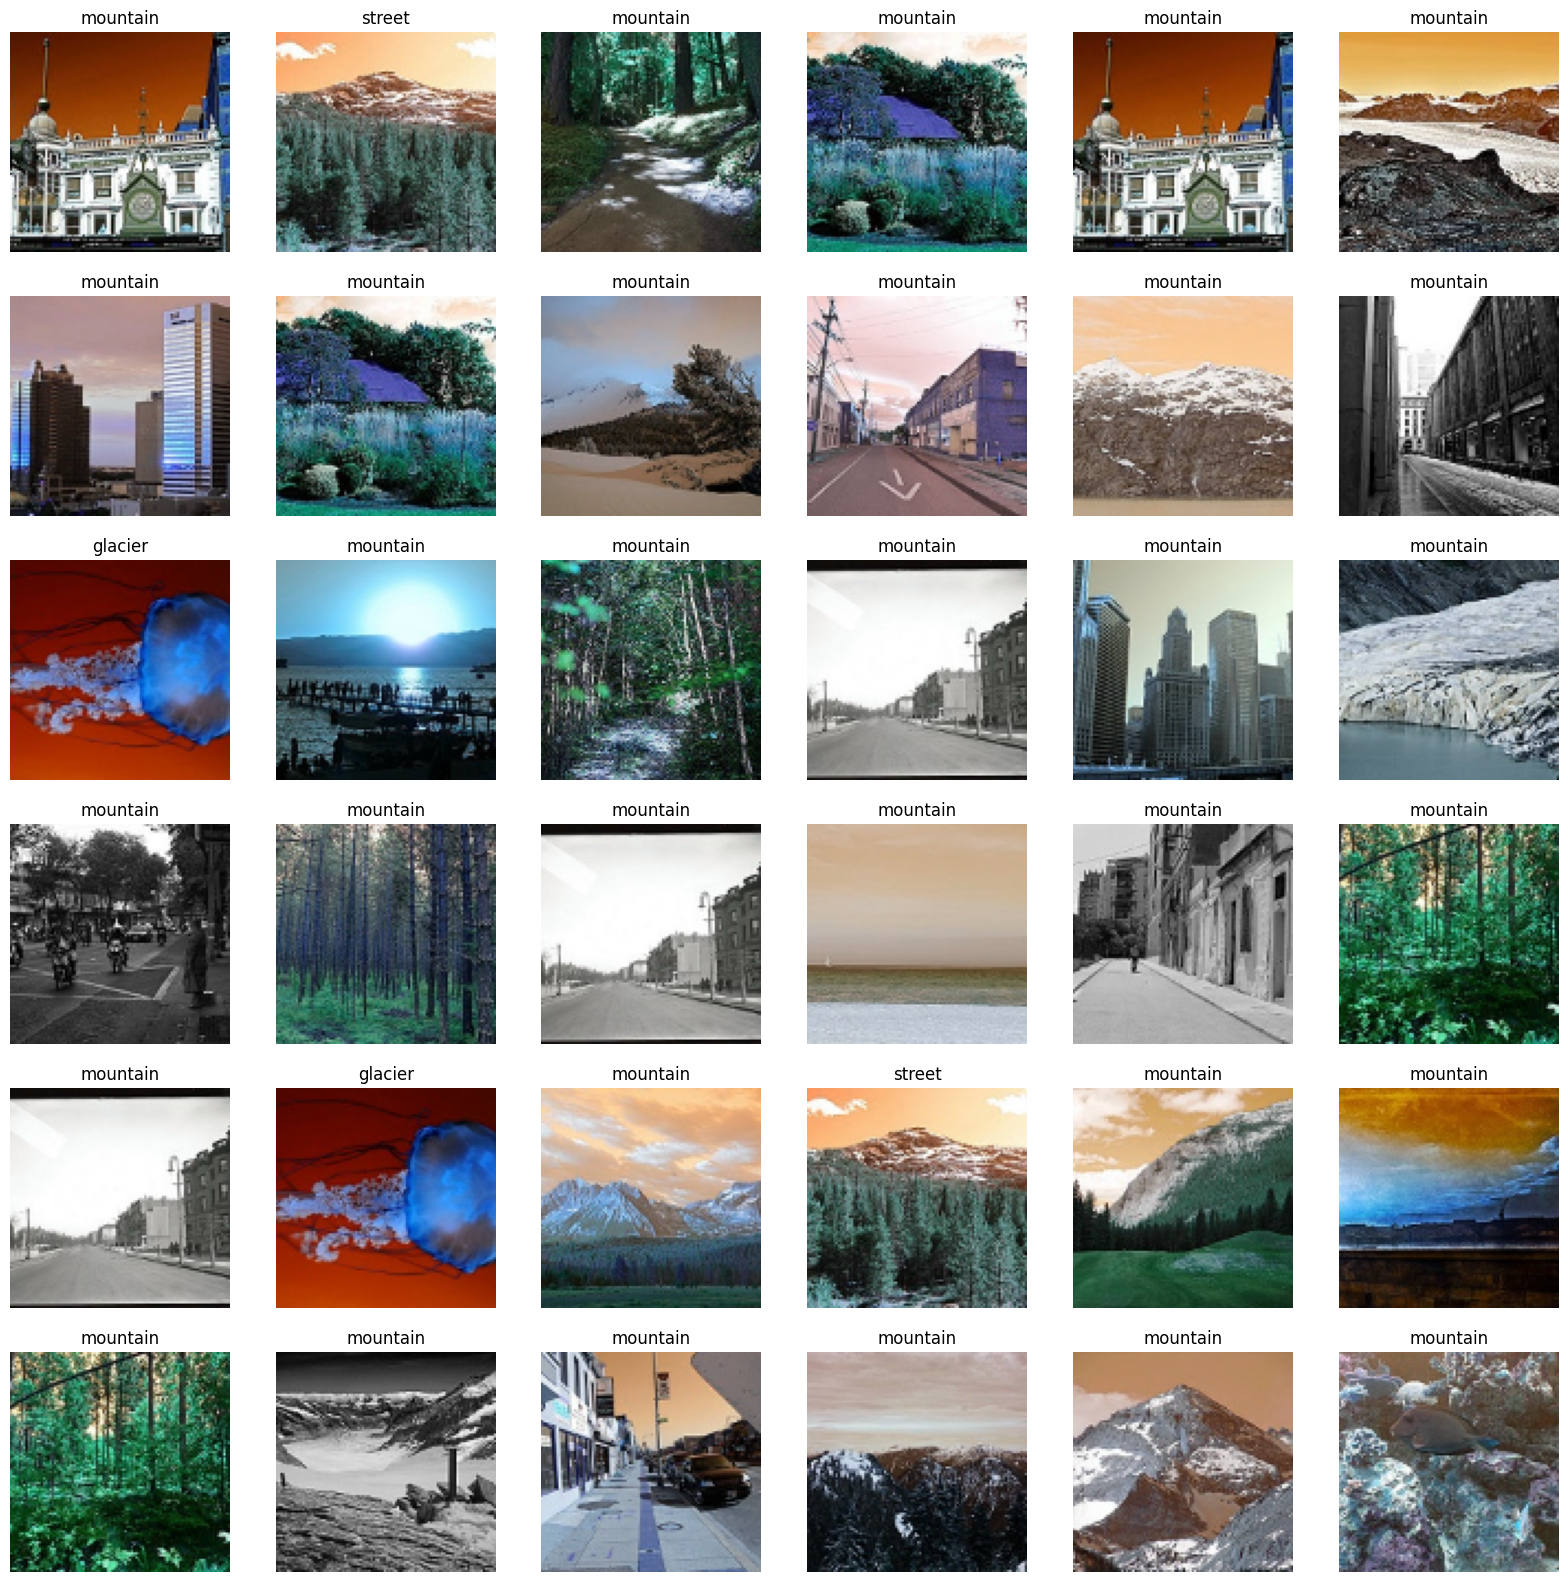

In [26]:
plt.figure(figsize=(20,20))
for n , i in enumerate(list(np.random.randint(0,len(x_pred),36))) :
    plt.subplot(6,6,n+1)
    plt.imshow(x_pred[i])
    plt.axis('off')
    plt.title(get_code(np.argmax(y_result[i])))